In [1]:
from datadlc import DataDLC
from plotting import Plotting
from dataneuron import DataNeuron
from mergeddata import MergedData

#### 1: DataDLC

In [2]:
data_dlc = DataDLC(
    r"C:\Python Programming\LIU\projects\Img_3740-3741_labeled\IMG_3740_convertedDLC_Resnet50_td_res50_2Mar13shuffle1_detector_200_snapshot_075.h5"
    )

In [3]:
data_dlc.impute_outliers(method='square_ransac',
                         model="HGBR",
                         min_samples=20,
                         residual_threshold=0.05,
                         max_trials=1000)

<Axes: >

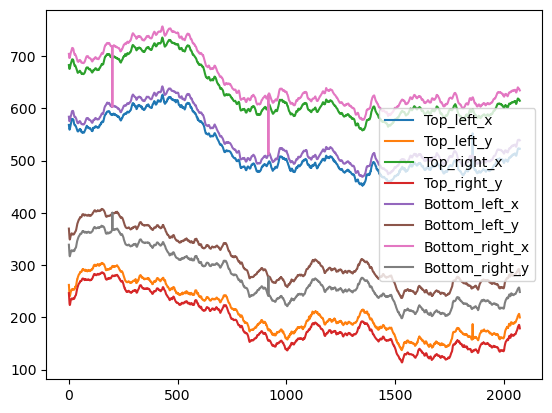

In [3]:
data_dlc.df_square.plot()

In [4]:
data_dlc.get_bending_coefficients()

0       0.001499
1       0.001399
2       0.001385
3       0.001381
4       0.001238
          ...   
2071    0.021115
2072    0.021578
2073    0.018366
2074    0.000176
2075    0.018743
Name: Bending_Coefficient, Length: 2076, dtype: float64

In [5]:
data_dlc.apply_homography()

,tf_FR1_x,tf_FR1_y,tf_FR2_x,tf_FR2_y,tf_FG1_x,tf_FG1_y,tf_FG2_x,tf_FG2_y,tf_FB1_x,tf_FB1_y,tf_FB2_x,tf_FB2_y
0,-235.607330,423.244446,-206.719055,379.410065,-173.807037,339.430420,-138.523483,302.344482,-106.238884,268.517334,-71.753067,238.309250
1,-230.565613,421.433441,-201.249207,377.462036,-169.812119,339.190002,-133.926651,300.383087,-101.490685,265.324646,-68.411400,235.926483
2,-221.258133,417.624451,-196.333084,379.543396,-162.026855,337.545441,-129.272156,299.191986,-97.248230,264.386230,-63.285706,233.297379
3,-214.955276,417.000488,-186.546951,373.371796,-155.704193,333.444458,-121.184723,294.546997,-88.449257,258.174072,-56.407375,227.298904
4,-211.425507,413.506989,-180.183914,369.290039,-147.707153,325.836060,-116.552757,290.372223,-81.674911,250.031876,-50.017021,220.698669
...,...,...,...,...,...,...,...,...,...,...,...,...
2071,183.475967,207.511169,-5.818035,217.816223,-4.030186,215.329330,82.604240,108.344345,83.073135,109.644768,88.478203,108.534370
2072,183.988922,207.720123,-4.381158,217.714752,-3.140494,214.789429,83.222633,107.209282,83.560997,108.146935,86.982224,108.176888
2073,183.518768,207.154373,-4.523307,218.139511,-3.240279,215.178726,204.565018,8.261100,188.497757,194.685196,11.688287,174.489914
2074,183.939178,207.507080,-3.732641,218.720764,-2.409154,215.386307,204.435486,8.187830,74.770302,105.858978,83.078232,102.610435


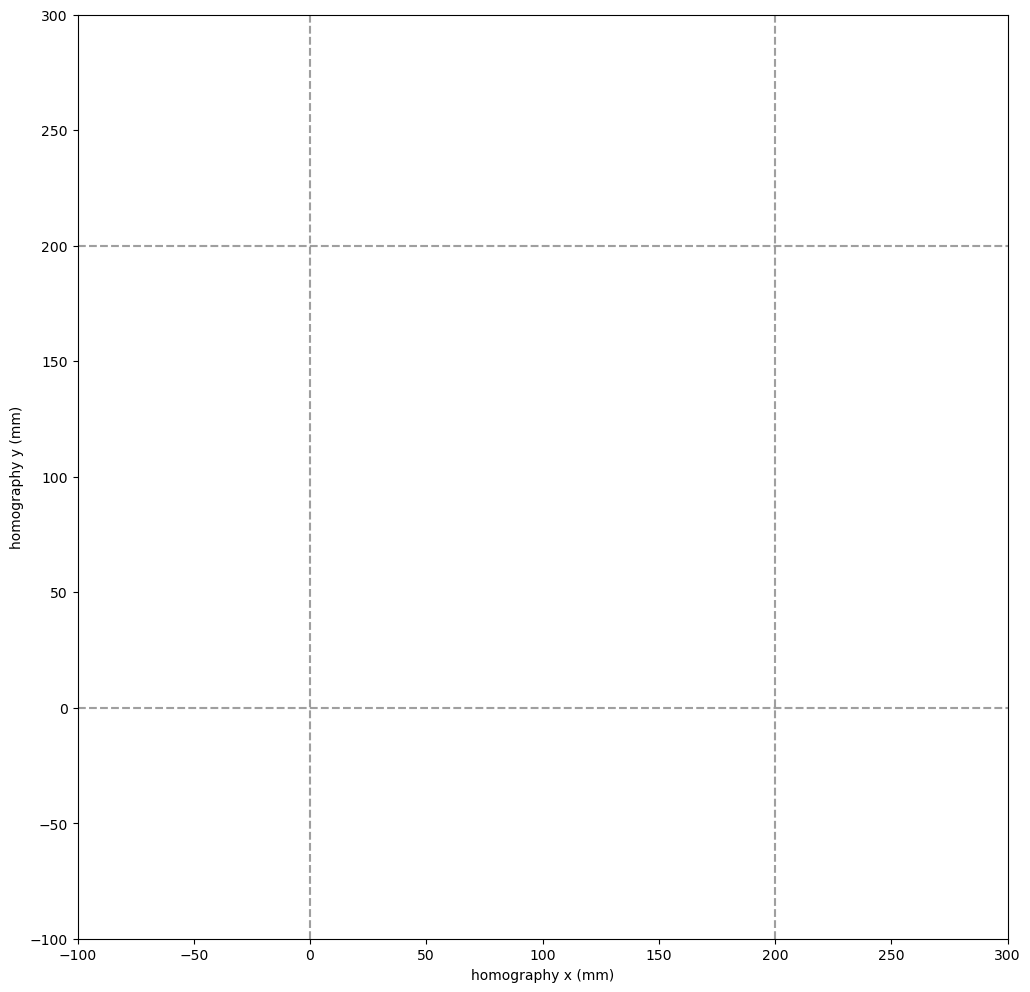

In [7]:
Plotting.plot_homography_animated(data_dlc.homography_points,
                                  data_dlc.df_transformed_monofil,
                                  "homography_animation_3740.mp4")

#### 2: DataNeuron

In [6]:
data_neuron = DataNeuron(
    r"C:\Python Programming\LIU\Data\nerve accel data\20250306_MP_018_radial_2Sel_unit_6_RF_mapp_1_3740.xlsx",
    100000
    )

c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\dataneuron.py:59: RuntimeWarning: divide by zero encountered in scalar divide
  current_freq = 1 / np.mean(time_diffs).round()


c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\plotting.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)


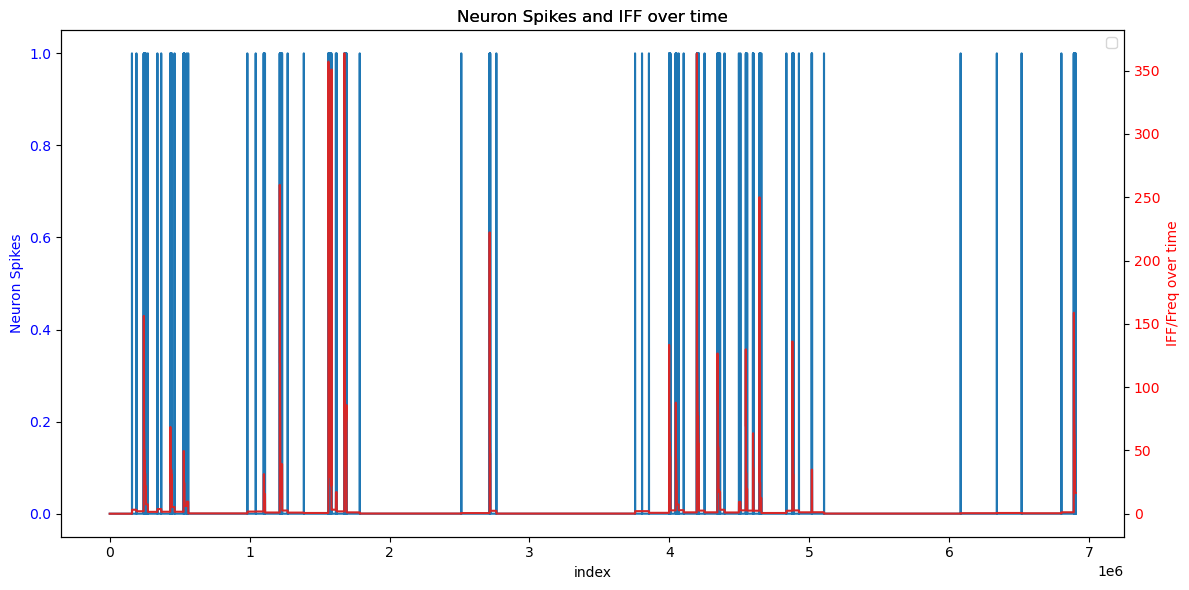

In [7]:
columns = data_neuron.df.columns

Plotting.plot_lines(data_neuron.df,
                    columns[1:],
                    xlabel="index",
                    ylabel_1="Neuron Spikes",
                    ylabel_2="IFF/Freq over time",
                    title="Neuron Spikes and IFF over time")

In [8]:
data_neuron.downsample(30) 

3333


,IFF,Spikes
0,0.000000,0.0
1,0.000000,0.0
2,0.000000,0.0
3,0.000000,0.0
4,0.000000,0.0
...,...,...
2067,1.129943,0.0
2068,158.730164,3.0
2069,101.010101,3.0
2070,61.728394,2.0


c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\plotting.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)


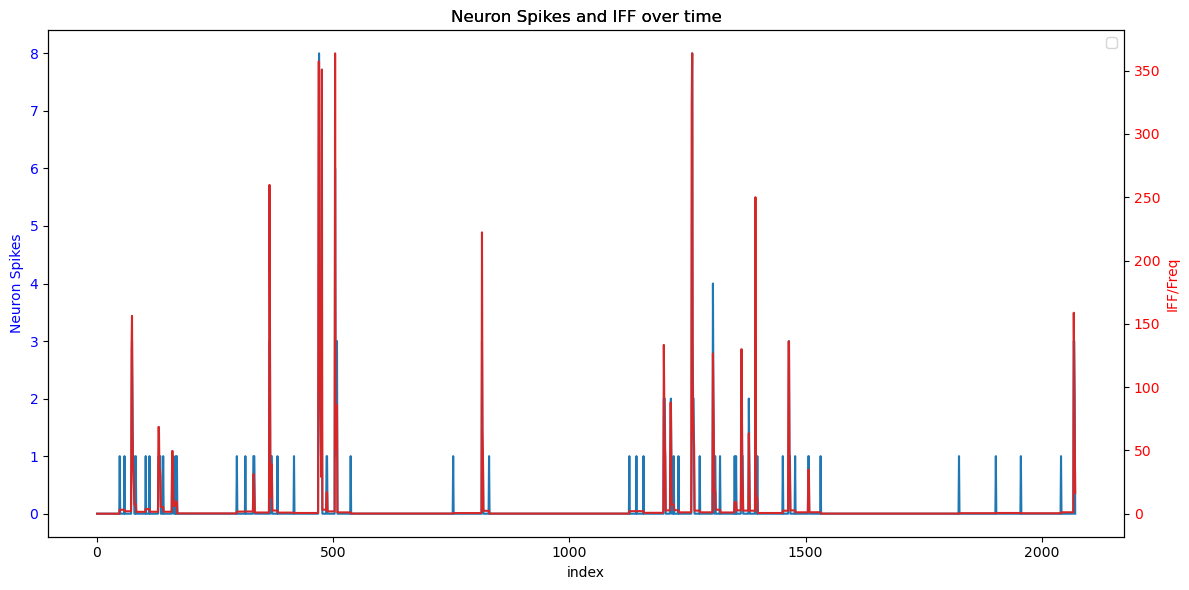

In [9]:
Plotting.plot_lines(data_neuron.downsampled_df,
                    columns[1:],
                    "index", "Neuron Spikes", "IFF/Freq",
                    "Neuron Spikes and IFF over time")

#### 3: MergeData

In [10]:
full_data = MergedData(data_dlc, data_neuron)

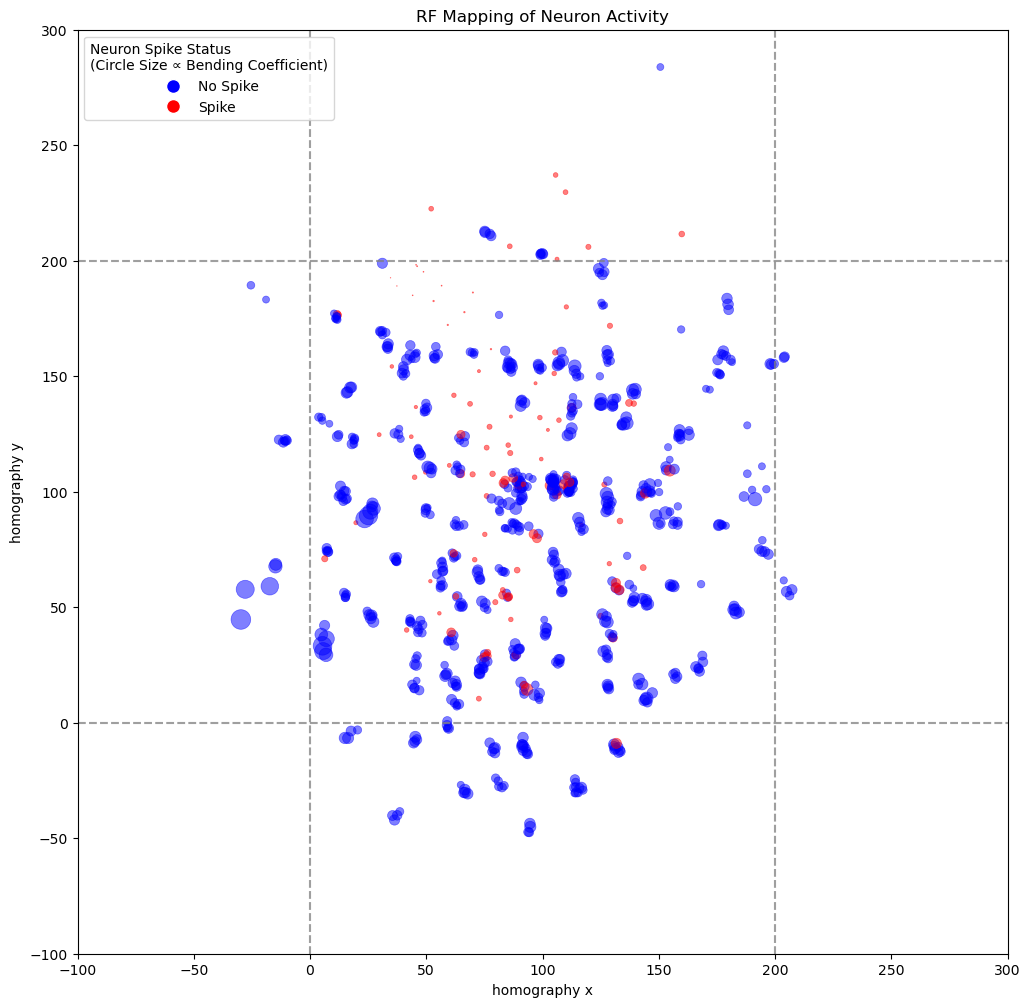

In [11]:
Plotting.plot_rf_mapping(full_data,
                         "tf_FB2_x", "tf_FB2_y",
                         "Bending_Coefficient",
                         "Spikes",
                         full_data.dlc.homography_points)

c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\plotting.py:217: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["scaled_size"] = scaler.fit_transform(df[[bending_col]])


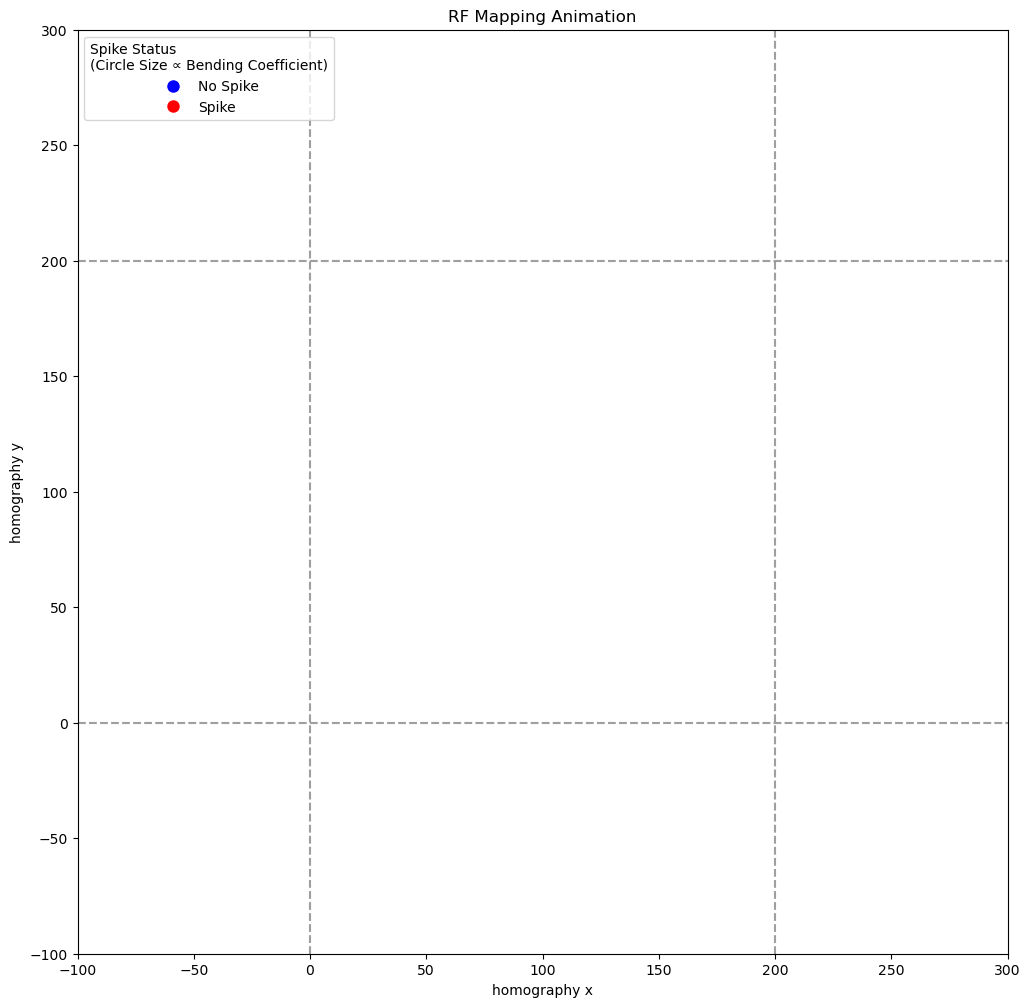

c:\Python Programming\LIU\RF_mapping\RF_mapping\post_processing\plotting.py:234: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x, y), size, color=color, alpha=0.5, edgecolor="k", linewidth=0.5)


KeyboardInterrupt: 

In [12]:
Plotting.plot_rf_mapping_animated(full_data,
                                  "tf_FB2_x", "tf_FB2_y",
                                  "Bending_Coefficient",
                                  "Spikes",
                                  full_data.dlc.homography_points,
                                  "rf_mapping_animation_3740.mp4")

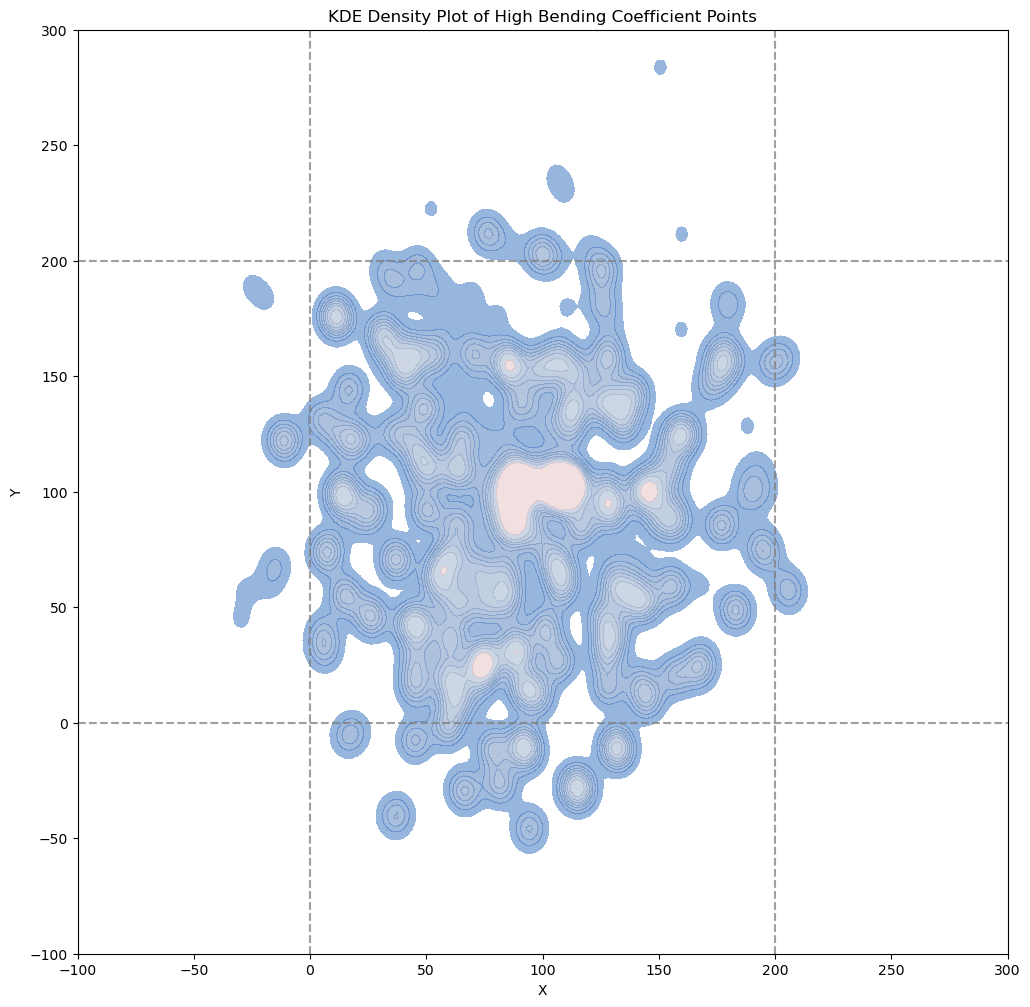

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'KDE Density Plot of High Bending Coefficient Points'}, xlabel='X', ylabel='Y'>)

In [13]:
Plotting.plot_kde_scatter(full_data,
                          "tf_FB2_x", "tf_FB2_y",
                          full_data.dlc.homography_points,
                          size="IFF",
                          title="KDE Density Plot of High Bending Coefficient Points",
                          kde=True,
                          scatter=False)

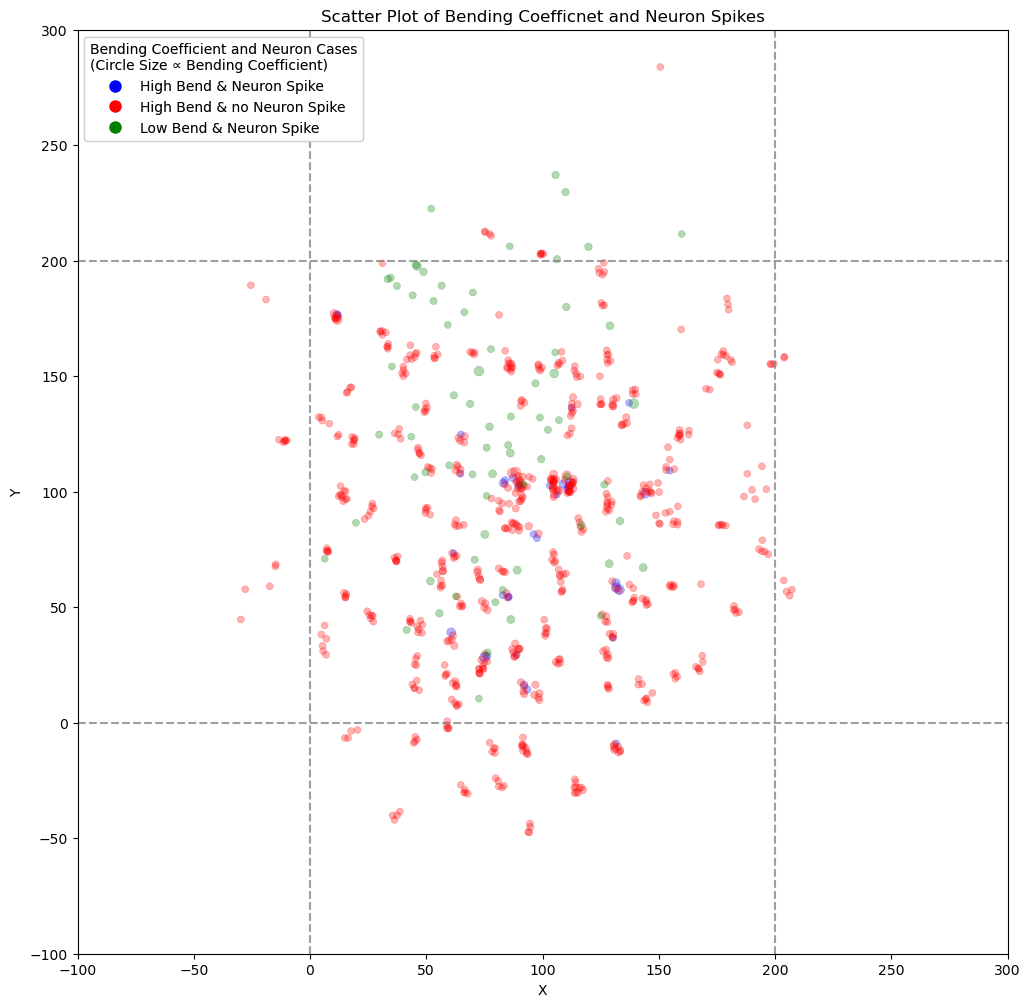

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Scatter Plot of Bending Coefficnet and Neuron Spikes'}, xlabel='X', ylabel='Y'>)

In [14]:
Plotting.plot_kde_scatter(full_data,
                          "tf_FB2_x", "tf_FB2_y",
                          full_data.dlc.homography_points,
                          size="IFF",
                          title="Scatter Plot of Bending Coefficnet and Neuron Spikes",
                          kde=False,
                          scatter=True)

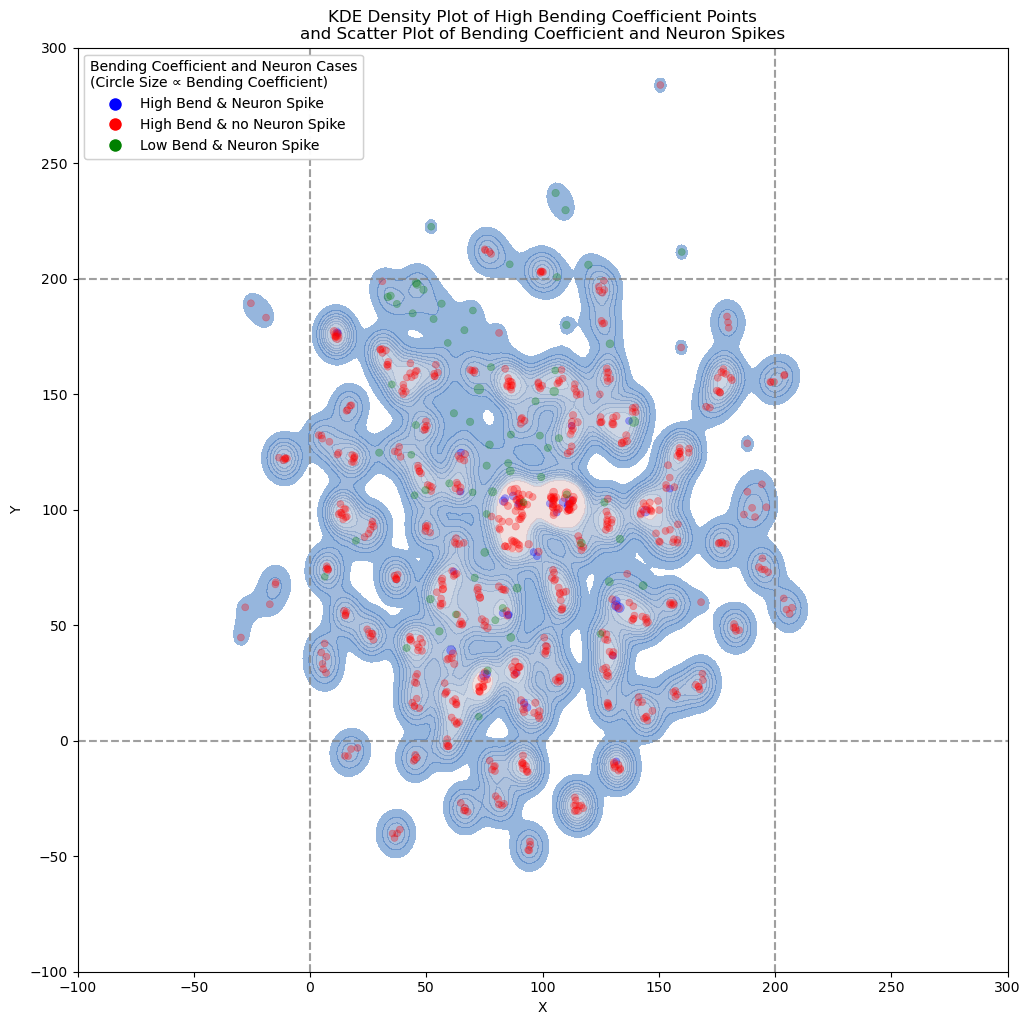

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'KDE Density Plot of High Bending Coefficient Points\nand Scatter Plot of Bending Coefficient and Neuron Spikes'}, xlabel='X', ylabel='Y'>)

In [15]:
Plotting.plot_kde_scatter(full_data,
                          "tf_FB2_x", "tf_FB2_y",
                          full_data.dlc.homography_points,
                          size="IFF",
                          title="KDE Density Plot of High Bending Coefficient Points" +
                                "\nand Scatter Plot of Bending Coefficient and Neuron Spikes",
                          kde=True,
                          scatter=True)

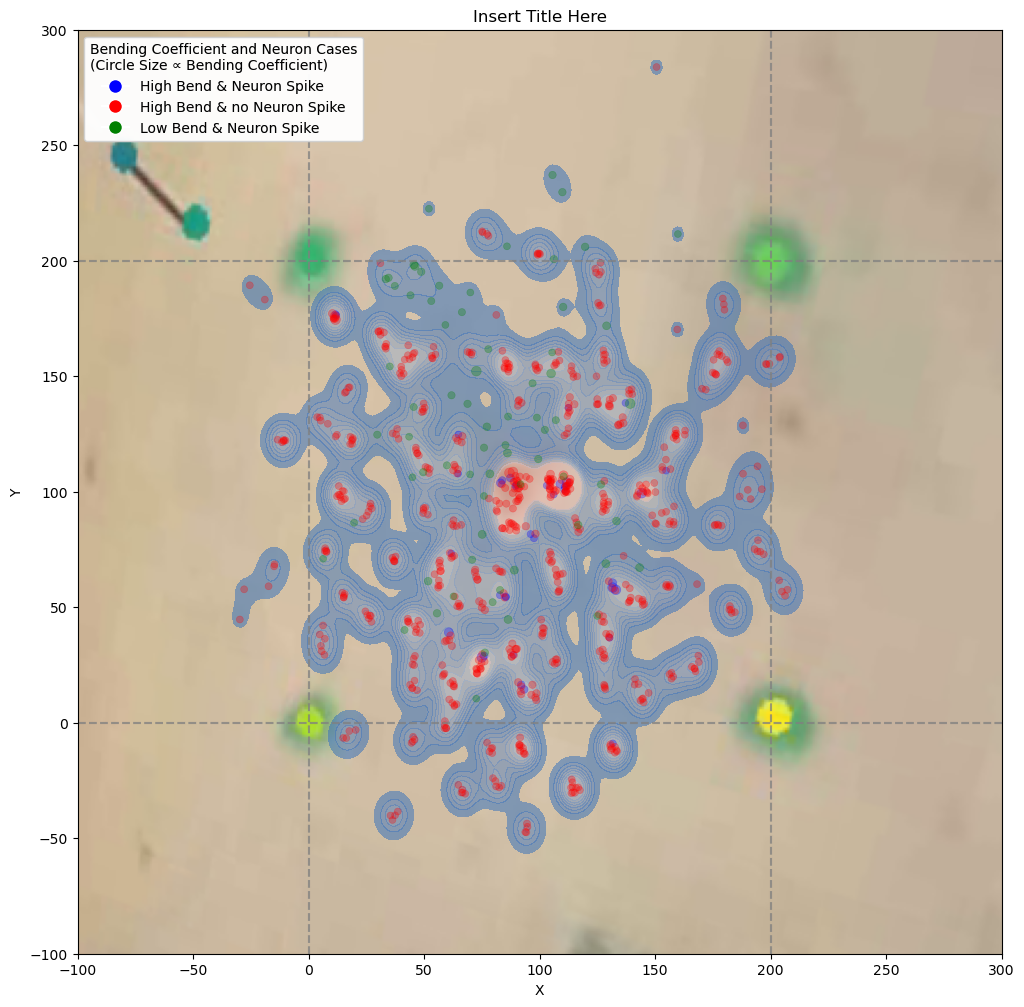

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Insert Title Here'}, xlabel='X', ylabel='Y'>)

In [16]:
index_frame = 5

Plotting.plot_kde_scatter(full_data,
                          "tf_FB2_x", "tf_FB2_y",
                          full_data.dlc.homography_points,
                          size="IFF",
                          title="Insert Title Here",
                          kde=True,
                          scatter=True,
                          # inputs for selecting a specific frame as background
                          frame=True,
                          video_path=r"C:\Python Programming\LIU\projects\Img_3740-3741_labeled\IMG_3740_convertedDLC_Resnet50_td_res_3Mar18shuffle1_detector_200_snapshot_075_p50_labeled.mp4",
                          index=index_frame)

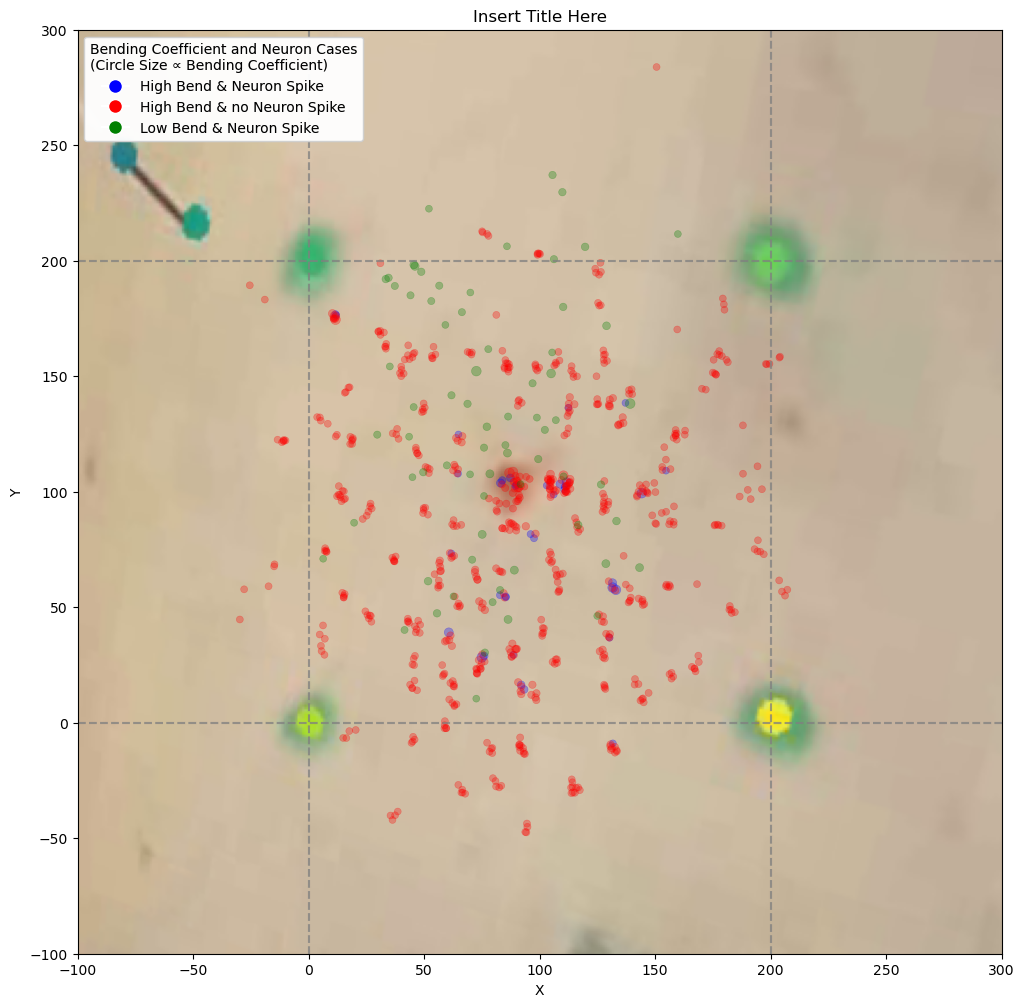

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Insert Title Here'}, xlabel='X', ylabel='Y'>)

In [18]:
Plotting.plot_kde_scatter(full_data,
                          "tf_FB2_x", "tf_FB2_y",
                          full_data.dlc.homography_points,
                          size="IFF",
                          title="Insert Title Here",
                          kde=False,
                          scatter=True,
                          # inputs for selecting a specific frame as background
                          frame=True,
                          video_path=r"C:\Python Programming\LIU\projects\Img_3740-3741_labeled\IMG_3740_convertedDLC_Resnet50_td_res_3Mar18shuffle1_detector_200_snapshot_075_p50_labeled.mp4",
                          index=index_frame)

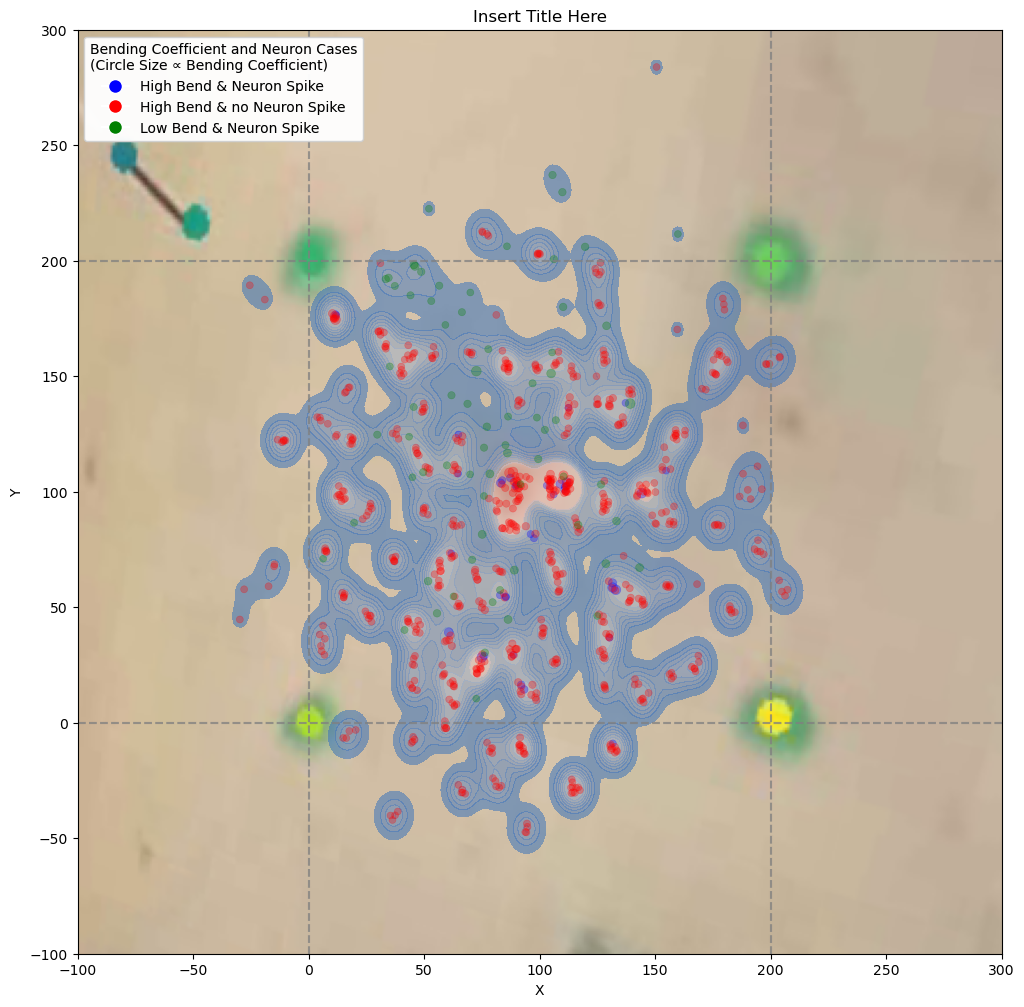

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Insert Title Here'}, xlabel='X', ylabel='Y'>)

In [19]:
Plotting.plot_kde_scatter(full_data,
                          "tf_FB2_x", "tf_FB2_y",
                          full_data.dlc.homography_points,
                          size="IFF",
                          title="Insert Title Here",
                          kde=True,
                          scatter=True,
                          # inputs for selecting a specific frame as background
                          frame=True,
                          video_path=r"C:\Python Programming\LIU\projects\Img_3740-3741_labeled\IMG_3740_convertedDLC_Resnet50_td_res_3Mar18shuffle1_detector_200_snapshot_075_p50_labeled.mp4",
                          index=index_frame)